# P8-2 Sectoral Uncertainty and Linkages

This notebook extends P6 and P8-1 into the second part of the P8 uncertainty framework.

**Purpose:** respond to Neil's 17 July feedback that the sectoral analysis should not only show central sector estimates, but should also discuss:

- uncertainty in sectoral decarbonisation rates;
- which sectors can move together;
- which sectors remain relatively independent or hard to abate;
- where negative emissions or credits may become relevant.

**Outputs produced by this notebook:**

- `p8_2_sector_rate_anchor_metrics.csv`
- `p8_2_sector_linkage_metadata.csv`
- `p8_2_sector_linkage_driver_matrix.csv`
- `p8_2_sector_uncertainty_band_2050.csv`
- `p8_2_sector_rate_anchor_scatter.jpg`
- `p8_2_sector_uncertainty_band_2050.jpg`
- `p8_2_sector_linkage_driver_matrix.jpg`
- `p8_2_results_summary_bilingual.txt`

**Interpretation note:** this is a stylised sensitivity and linkage framework, not a probabilistic model. It is intended to make the uncertainty discussion more rigorous without pretending to forecast exact sector probabilities.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


def find_project_root(start=None):
    candidates = []
    if start is not None:
        candidates.append(Path(start).resolve())
    try:
        candidates.append(Path.cwd().resolve())
    except Exception:
        pass
    candidates += [Path(r"E:\UCL Final Essay"), Path.home() / "Downloads"]
    checked = []
    for base in candidates:
        for candidate in [base] + list(base.parents):
            if candidate in checked:
                continue
            checked.append(candidate)
            if (candidate / "p6_sector_analysis" / "data_processed").exists() and (candidate / "p4_p5_local_reproduction" / "tables").exists():
                return candidate
    raise FileNotFoundError("Could not find project root. Please run this notebook from inside the dissertation project folder.")


PROJECT_ROOT = find_project_root()
P6_DIR = PROJECT_ROOT / "p6_sector_analysis"
P5_TABLE_DIR = PROJECT_ROOT / "p4_p5_local_reproduction" / "tables"
OUTPUT_ROOT = PROJECT_ROOT / "p8_uncertainty_framework"
TABLE_DIR = OUTPUT_ROOT / "tables"
FIG_DIR = OUTPUT_ROOT / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Output root:", OUTPUT_ROOT)

Project root: E:\UCL Final Essay
Output root: E:\UCL Final Essay\p8_uncertainty_framework


## 1. Load P6 Sector Data and CCC Bridge

The sectoral time series comes from the P6 cleaned DESNZ TES-sector table. This keeps the historical and projected sector categories internally consistent for P8-2.

The CCC sector bridge is used cautiously as a 2050 target-consistent comparator. It is not treated as a perfect one-to-one sector mapping.

In [2]:
sector_long_path = P6_DIR / "data_processed" / "p6_desnz_tes_reference_sector_long.csv"
sector_change_path = P6_DIR / "tables" / "p6_sector_change_2023_to_2050.csv"
ccc_bridge_path = P5_TABLE_DIR / "p5_ccc_desnz_sector_alignment.csv"

for p in [sector_long_path, sector_change_path, ccc_bridge_path]:
    assert p.exists(), f"Missing required input file: {p}"

sector_long = pd.read_csv(sector_long_path)
sector_change = pd.read_csv(sector_change_path)
ccc_bridge = pd.read_csv(ccc_bridge_path)

sector_long["tes_sector"] = sector_long["tes_sector"].astype(str)
sector_long["year"] = sector_long["year"].astype(int)
sector_long["emissions_MtCO2e"] = pd.to_numeric(sector_long["emissions_MtCO2e"], errors="coerce")

print("Sector long shape:", sector_long.shape)
print("Years:", sector_long["year"].min(), "-", sector_long["year"].max())
print("Sectors:", ", ".join(sorted(sector_long["tes_sector"].unique())))

display(sector_long.head())
display(ccc_bridge)

Sector long shape: (549, 4)
Years: 1990 - 2050
Sectors: Agriculture, Buildings and product uses, Domestic Transport, Electricity supply, Fuel supply, IAS, Industry, LULUCF, Waste


,scenario,tes_sector,year,emissions_MtCO2e
0,Reference,Agriculture,1990,54.398582
1,Reference,Agriculture,1991,54.210997
2,Reference,Agriculture,1992,53.850146
3,Reference,Agriculture,1993,52.961588
4,Reference,Agriculture,1994,53.733133


,desnz_tes_sector,ccc7_sector_match,alignment_type,desnz_2050_MtCO2e,ccc7_2050_MtCO2e,recommended_use,notes
0,Agriculture,Agriculture,Direct,38.2,26.4,Can be compared directly at broad sector level.,"Strongest sector-level match, subject to sourc..."
1,Buildings and product uses,Residential buildings + Non-residential buildi...,Aggregate / partial,84.6,2.7,Use cautiously for broad comparison only; not ...,DESNZ combines buildings and product uses; CCC...
2,Domestic Transport,Surface transport; aviation/shipping treated s...,Partial,49.9,1.1,Use surface transport as a proxy for road/surf...,"CCC separates surface transport, aviation and ..."
3,Electricity supply,Electricity supply,Direct,41.0,1.0,Can be compared directly at broad sector level.,Strong match; note energy-from-waste classific...
4,Fuel supply,Fuel supply,Direct,13.2,1.6,Can be compared directly at broad sector level.,Broad sector match.
5,IAS,Aviation + Shipping,Aggregate / partial,34.0,23.2,Use cautiously for broad IAS-related compariso...,CCC has Aviation and Shipping as separate sect...
6,Industry,Industry,Direct / broad,47.4,3.6,Can be compared at broad level; keep caveat ar...,"Mostly usable, but F-gas/product-use boundarie..."
7,LULUCF,Land use only,Partial / not one-to-one,4.4,-29.9,Do not compare as exact match; use qualitative...,CCC land use is negative in 2050; engineered r...
8,Waste,Waste,Direct / broad,11.7,5.1,Can be compared at broad level with caveat aro...,Sector classification includes some energy-fro...
9,(no direct DESNZ TES equivalent),Engineered removals,CCC-only benchmark sector,NaN,-35.8,Report separately; do not allocate to a DESNZ ...,This sector is essential to the CCC net-zero b...


## 2. Sectoral Rate Anchors

This step compares projected DESNZ sector reduction rates with historical delivered rates.

Positive values mean emissions reduction. Negative values mean emissions increase.

In [3]:
selected_years = [1990, 2008, 2018, 2023, 2030, 2035, 2050]
pivot = (
    sector_long[sector_long["year"].isin(selected_years)]
    .pivot_table(index="tes_sector", columns="year", values="emissions_MtCO2e", aggfunc="first")
    .reset_index()
)
pivot.columns = [str(c) if isinstance(c, int) else c for c in pivot.columns]

required = [str(y) for y in selected_years]
missing = [c for c in required if c not in pivot.columns]
assert not missing, f"Missing selected years in sector table: {missing}"

def reduction_rate(row, start, end):
    return (row[str(start)] - row[str(end)]) / (end - start)

metrics = pivot.copy()
metrics["hist_rate_1990_2023_MtCO2e_per_year"] = metrics.apply(lambda r: reduction_rate(r, 1990, 2023), axis=1)
metrics["hist_rate_2008_2023_MtCO2e_per_year"] = metrics.apply(lambda r: reduction_rate(r, 2008, 2023), axis=1)
metrics["hist_rate_2018_2023_MtCO2e_per_year"] = metrics.apply(lambda r: reduction_rate(r, 2018, 2023), axis=1)
metrics["projected_rate_2023_2050_MtCO2e_per_year"] = metrics.apply(lambda r: reduction_rate(r, 2023, 2050), axis=1)
metrics["projected_rate_2035_2050_MtCO2e_per_year"] = metrics.apply(lambda r: reduction_rate(r, 2035, 2050), axis=1)

hist_cols = [
    "hist_rate_1990_2023_MtCO2e_per_year",
    "hist_rate_2008_2023_MtCO2e_per_year",
    "hist_rate_2018_2023_MtCO2e_per_year",
]
metrics["best_positive_historical_rate_MtCO2e_per_year"] = metrics[hist_cols].clip(lower=0).max(axis=1)
metrics["projected_vs_best_historical_rate_ratio"] = np.where(
    metrics["best_positive_historical_rate_MtCO2e_per_year"] > 0,
    metrics["projected_rate_2023_2050_MtCO2e_per_year"] / metrics["best_positive_historical_rate_MtCO2e_per_year"],
    np.nan,
)

def classify_rate(row):
    projected = row["projected_rate_2023_2050_MtCO2e_per_year"]
    best_hist = row["best_positive_historical_rate_MtCO2e_per_year"]
    ratio = row["projected_vs_best_historical_rate_ratio"]
    if projected < 0 and best_hist > 0:
        return "Projected reversal after historical decline"
    if best_hist <= 0 and projected <= 0:
        return "No delivered decline anchor; projected increase or flat path"
    if ratio < 0.25:
        return "Much slower than historical delivered rates"
    if ratio < 0.75:
        return "Slower than historical delivered rates"
    if ratio <= 1.25:
        return "Comparable to historical delivered rates"
    return "Faster than historical delivered rates"

metrics["rate_anchor_interpretation"] = metrics.apply(classify_rate, axis=1)

rank_cols = ["tes_sector", "share_of_2050_inc_IAS_total_pct", "rank_2050_residual"]
metrics = metrics.merge(sector_change[rank_cols], on="tes_sector", how="left")
metrics = metrics.sort_values("rank_2050_residual")

out_cols = [
    "tes_sector",
    "1990", "2008", "2018", "2023", "2030", "2035", "2050",
    "hist_rate_1990_2023_MtCO2e_per_year",
    "hist_rate_2008_2023_MtCO2e_per_year",
    "hist_rate_2018_2023_MtCO2e_per_year",
    "projected_rate_2023_2050_MtCO2e_per_year",
    "projected_rate_2035_2050_MtCO2e_per_year",
    "best_positive_historical_rate_MtCO2e_per_year",
    "projected_vs_best_historical_rate_ratio",
    "rate_anchor_interpretation",
    "share_of_2050_inc_IAS_total_pct",
    "rank_2050_residual",
]
metrics[out_cols].to_csv(TABLE_DIR / "p8_2_sector_rate_anchor_metrics.csv", index=False)
display(metrics[out_cols].round(2))

,tes_sector,1990,2008,2018,2023,2030,2035,2050,hist_rate_1990_2023_MtCO2e_per_year,hist_rate_2008_2023_MtCO2e_per_year,hist_rate_2018_2023_MtCO2e_per_year,projected_rate_2023_2050_MtCO2e_per_year,projected_rate_2035_2050_MtCO2e_per_year,best_positive_historical_rate_MtCO2e_per_year,projected_vs_best_historical_rate_ratio,rate_anchor_interpretation,share_of_2050_inc_IAS_total_pct,rank_2050_residual
1,Buildings and product uses,109.75,113.32,97.93,78.48,82.16,81.72,84.55,0.95,2.32,3.89,-0.22,-0.19,3.89,-0.06,Projected reversal after historical decline,26.07,1
2,Domestic Transport,129.26,134.17,128.12,111.81,94.66,71.19,49.88,0.53,1.49,3.26,2.29,1.42,3.26,0.70,Slower than historical delivered rates,15.38,2
6,Industry,155.21,92.83,63.21,53.05,40.12,40.71,47.37,3.10,2.65,2.03,0.21,-0.44,3.10,0.07,Much slower than historical delivered rates,14.61,3
3,Electricity supply,203.99,172.94,65.85,43.93,23.66,29.26,40.96,4.85,8.60,4.38,0.11,-0.78,8.60,0.01,Much slower than historical delivered rates,12.63,4
0,Agriculture,54.40,49.70,48.10,46.61,44.65,43.53,38.20,0.24,0.21,0.30,0.31,0.36,0.30,1.05,Comparable to historical delivered rates,11.78,5
5,IAS,23.65,45.78,44.47,39.47,40.26,38.38,34.05,-0.48,0.42,1.00,0.20,0.29,1.00,0.20,Much slower than historical delivered rates,10.50,6
4,Fuel supply,77.19,49.68,37.26,30.10,25.19,20.98,13.24,1.43,1.31,1.43,0.62,0.52,1.43,0.44,Slower than historical delivered rates,4.08,7
8,Waste,70.29,44.12,23.13,19.87,15.94,13.15,11.68,1.53,1.62,0.65,0.30,0.10,1.62,0.19,Much slower than historical delivered rates,3.60,8
7,LULUCF,10.62,1.23,0.68,1.12,1.34,2.86,4.36,0.29,0.01,-0.09,-0.12,-0.10,0.29,-0.42,Projected reversal after historical decline,1.34,9


## 3. Sector Linkage Metadata

This table converts Neil's qualitative feedback into an explicit analytical structure: some sectors move together through clean power and electrification, while others remain harder or more independent.

In [4]:
linkage_rows = [
    {
        "tes_sector": "Electricity supply",
        "linkage_group": "System-enabling clean-power sector",
        "primary_uncertainty_drivers": "Renewables build-out; grid; storage/flexibility; gas backup; electricity demand growth",
        "can_move_together_with": "Domestic Transport; Buildings and product uses; parts of Industry",
        "relatively_independent_from": "Agriculture; IAS; some industrial process emissions",
        "negative_emissions_or_credits_relevance": "Indirect; residual gas power could require removals or CCS",
        "interpretation_for_dissertation": "Clean electricity is an enabling condition: transport and building electrification only reduce emissions fully if power decarbonises.",
    },
    {
        "tes_sector": "Domestic Transport",
        "linkage_group": "Electrification-coupled demand sector",
        "primary_uncertainty_drivers": "EV uptake; charging infrastructure; travel demand; clean electricity availability",
        "can_move_together_with": "Electricity supply; Buildings and product uses through consumer technology uptake and infrastructure delivery",
        "relatively_independent_from": "Agriculture; LULUCF",
        "negative_emissions_or_credits_relevance": "Limited for surface transport; more relevant if residual liquid-fuel use persists",
        "interpretation_for_dissertation": "Domestic transport can decline quickly if electrification and infrastructure delivery remain aligned.",
    },
    {
        "tes_sector": "Buildings and product uses",
        "linkage_group": "Electrification and end-use technology sector",
        "primary_uncertainty_drivers": "Heat pumps; building fabric; consumer uptake; fuel prices; F-gases/product-use boundaries",
        "can_move_together_with": "Electricity supply; Domestic Transport through electrification infrastructure and consumer adoption",
        "relatively_independent_from": "Agriculture; IAS",
        "negative_emissions_or_credits_relevance": "Potentially relevant if residual heating/product-use emissions remain high",
        "interpretation_for_dissertation": "The DESNZ projection is a warning case because this sector rises after 2023 despite historical decline.",
    },
    {
        "tes_sector": "Industry",
        "linkage_group": "Partly linked hard-to-abate sector",
        "primary_uncertainty_drivers": "Industrial output; energy efficiency; electrification; hydrogen; CCUS; process emissions",
        "can_move_together_with": "Electricity supply; Fuel supply; hydrogen/CCUS infrastructure",
        "relatively_independent_from": "Residential behaviour; agriculture-specific biological emissions",
        "negative_emissions_or_credits_relevance": "Relevant for residual process emissions if direct abatement remains limited",
        "interpretation_for_dissertation": "Industry is partly coupled to energy-system change but has independent process-emissions risks.",
    },
    {
        "tes_sector": "Agriculture",
        "linkage_group": "Biological non-CO2 residual sector",
        "primary_uncertainty_drivers": "Methane/nitrous oxide abatement; land use; diets; productivity; livestock numbers",
        "can_move_together_with": "LULUCF through land-use choices",
        "relatively_independent_from": "Electricity supply; surface-transport electrification",
        "negative_emissions_or_credits_relevance": "Highly relevant: residual agricultural emissions may need to be balanced by removals",
        "interpretation_for_dissertation": "Agriculture is a persistent residual because its emissions are not mainly solved by clean electricity.",
    },
    {
        "tes_sector": "IAS",
        "linkage_group": "International fuel and demand exposure sector",
        "primary_uncertainty_drivers": "Aviation/shipping demand; SAF/e-fuels; international regulation; fuel costs; credits",
        "can_move_together_with": "Industry and fuel supply through low-carbon fuels, but only partially",
        "relatively_independent_from": "Domestic power-sector decarbonisation",
        "negative_emissions_or_credits_relevance": "Very high: aviation/shipping residuals may need negative emissions or credits",
        "interpretation_for_dissertation": "IAS is a key near-miss risk because it can remain high even when domestic sectors improve.",
    },
    {
        "tes_sector": "Fuel supply",
        "linkage_group": "Fossil-system phase-down sector",
        "primary_uncertainty_drivers": "Fossil fuel demand; refinery/gas infrastructure; methane leakage; energy security choices",
        "can_move_together_with": "Domestic Transport; Buildings and product uses; Industry",
        "relatively_independent_from": "Agricultural non-CO2 emissions",
        "negative_emissions_or_credits_relevance": "Relevant if fossil infrastructure remains in use",
        "interpretation_for_dissertation": "Fuel supply falls when the wider energy system moves away from fossil fuels.",
    },
    {
        "tes_sector": "Waste",
        "linkage_group": "Methane and circular-economy sector",
        "primary_uncertainty_drivers": "Waste volumes; landfill methane; recycling/circular economy; energy-from-waste classification",
        "can_move_together_with": "Industry and buildings only weakly through material demand",
        "relatively_independent_from": "Power-sector decarbonisation",
        "negative_emissions_or_credits_relevance": "Possible, but usually secondary compared with agriculture/IAS/industry",
        "interpretation_for_dissertation": "Waste is smaller than the leading sectors but remains a policy-delivery residual.",
    },
    {
        "tes_sector": "LULUCF",
        "linkage_group": "Land-use accounting and removals-adjacent sector",
        "primary_uncertainty_drivers": "Afforestation; peatland; land management; accounting treatment; climate impacts",
        "can_move_together_with": "Agriculture through land-use choices",
        "relatively_independent_from": "Electricity and transport electrification",
        "negative_emissions_or_credits_relevance": "Very high, but accounting must be separated from engineered removals",
        "interpretation_for_dissertation": "LULUCF is volatile and must not be treated as a simple direct substitute for engineered removals.",
    },
]

linkage_metadata = pd.DataFrame(linkage_rows)
linkage_metadata.to_csv(TABLE_DIR / "p8_2_sector_linkage_metadata.csv", index=False)
display(linkage_metadata)

,tes_sector,linkage_group,primary_uncertainty_drivers,can_move_together_with,relatively_independent_from,negative_emissions_or_credits_relevance,interpretation_for_dissertation
0,Electricity supply,System-enabling clean-power sector,Renewables build-out; grid; storage/flexibilit...,Domestic Transport; Buildings and product uses...,Agriculture; IAS; some industrial process emis...,Indirect; residual gas power could require rem...,Clean electricity is an enabling condition: tr...
1,Domestic Transport,Electrification-coupled demand sector,EV uptake; charging infrastructure; travel dem...,Electricity supply; Buildings and product uses...,Agriculture; LULUCF,Limited for surface transport; more relevant i...,Domestic transport can decline quickly if elec...
2,Buildings and product uses,Electrification and end-use technology sector,Heat pumps; building fabric; consumer uptake; ...,Electricity supply; Domestic Transport through...,Agriculture; IAS,Potentially relevant if residual heating/produ...,The DESNZ projection is a warning case because...
3,Industry,Partly linked hard-to-abate sector,Industrial output; energy efficiency; electrif...,Electricity supply; Fuel supply; hydrogen/CCUS...,Residential behaviour; agriculture-specific bi...,Relevant for residual process emissions if dir...,Industry is partly coupled to energy-system ch...
4,Agriculture,Biological non-CO2 residual sector,Methane/nitrous oxide abatement; land use; die...,LULUCF through land-use choices,Electricity supply; surface-transport electrif...,Highly relevant: residual agricultural emissio...,Agriculture is a persistent residual because i...
5,IAS,International fuel and demand exposure sector,Aviation/shipping demand; SAF/e-fuels; interna...,Industry and fuel supply through low-carbon fu...,Domestic power-sector decarbonisation,Very high: aviation/shipping residuals may nee...,IAS is a key near-miss risk because it can rem...
6,Fuel supply,Fossil-system phase-down sector,Fossil fuel demand; refinery/gas infrastructur...,Domestic Transport; Buildings and product uses...,Agricultural non-CO2 emissions,Relevant if fossil infrastructure remains in use,Fuel supply falls when the wider energy system...
7,Waste,Methane and circular-economy sector,Waste volumes; landfill methane; recycling/cir...,Industry and buildings only weakly through mat...,Power-sector decarbonisation,"Possible, but usually secondary compared with ...",Waste is smaller than the leading sectors but ...
8,LULUCF,Land-use accounting and removals-adjacent sector,Afforestation; peatland; land management; acco...,Agriculture through land-use choices,Electricity and transport electrification,"Very high, but accounting must be separated fr...",LULUCF is volatile and must not be treated as ...


## 4. Driver Matrix

Scores are qualitative anchors:

- 0 = weak or indirect relevance
- 1 = moderate relevance
- 2 = strong relevance

This makes the 2x2 uncertainty framework easier to connect to sectoral results.

In [5]:
driver_scores = {
    "Electricity supply":              [2, 1, 1, 1, 0, 1, 1],
    "Domestic Transport":             [2, 2, 0, 2, 0, 1, 1],
    "Buildings and product uses":     [2, 2, 0, 2, 0, 1, 1],
    "Industry":                       [1, 1, 2, 1, 0, 2, 2],
    "Agriculture":                    [0, 0, 0, 2, 2, 1, 2],
    "IAS":                            [0, 0, 1, 2, 0, 2, 2],
    "Fuel supply":                    [1, 1, 1, 1, 0, 2, 1],
    "Waste":                          [0, 0, 0, 1, 1, 0, 1],
    "LULUCF":                         [0, 0, 0, 1, 2, 1, 2],
}

driver_cols = [
    "clean_power_dependency",
    "electrification_infrastructure",
    "hydrogen_ccus_dependency",
    "demand_behaviour",
    "land_bio_nonco2",
    "international_fuel_technology",
    "removals_credits_accounting",
]

driver_matrix = (
    pd.DataFrame.from_dict(driver_scores, orient="index", columns=driver_cols)
    .reset_index()
    .rename(columns={"index": "tes_sector"})
)
driver_matrix = driver_matrix.merge(metrics[["tes_sector", "rank_2050_residual"]], on="tes_sector", how="left").sort_values("rank_2050_residual")
driver_matrix.to_csv(TABLE_DIR / "p8_2_sector_linkage_driver_matrix.csv", index=False)
display(driver_matrix)

,tes_sector,clean_power_dependency,electrification_infrastructure,hydrogen_ccus_dependency,demand_behaviour,land_bio_nonco2,international_fuel_technology,removals_credits_accounting,rank_2050_residual
2,Buildings and product uses,2,2,0,2,0,1,1,1
1,Domestic Transport,2,2,0,2,0,1,1,2
3,Industry,1,1,2,1,0,2,2,3
0,Electricity supply,2,1,1,1,0,1,1,4
4,Agriculture,0,0,0,2,2,1,2,5
5,IAS,0,0,1,2,0,2,2,6
6,Fuel supply,1,1,1,1,0,2,1,7
7,Waste,0,0,0,1,1,0,1,8
8,LULUCF,0,0,0,1,2,1,2,9


## 5. Stylised 2050 Sectoral Uncertainty Band

This is a deliberately simple sensitivity band:

- **Accelerated / historical-rate anchor:** applies the fastest positive historical or central projected rate through 2050, floored at zero for direct positive-emissions sectors.
- **DESNZ central:** the DESNZ EEP reference sector value in 2050.
- **Delayed delivery:** assumes only half of the central projected reduction from 2023 to 2050 is achieved; for sectors projected to rise, it keeps the higher residual.

This is not a forecast. It is a transparent way to discuss whether central sector outcomes could be lower or higher under different delivery conditions.

In [6]:
uncertainty = metrics[[
    "tes_sector", "2023", "2050", "projected_rate_2023_2050_MtCO2e_per_year",
    "best_positive_historical_rate_MtCO2e_per_year", "rank_2050_residual",
]].copy()

years_to_2050 = 2050 - 2023

def accelerated_value(row):
    rate = max(
        0,
        row["projected_rate_2023_2050_MtCO2e_per_year"],
        row["best_positive_historical_rate_MtCO2e_per_year"],
    )
    return max(0, row["2023"] - rate * years_to_2050)

def delayed_value(row):
    central_change = row["2023"] - row["2050"]
    if central_change > 0:
        return row["2023"] - 0.5 * central_change
    return max(row["2023"], row["2050"])

uncertainty["accelerated_historical_anchor_2050_MtCO2e"] = uncertainty.apply(accelerated_value, axis=1)
uncertainty["desnz_central_2050_MtCO2e"] = uncertainty["2050"]
uncertainty["delayed_delivery_2050_MtCO2e"] = uncertainty.apply(delayed_value, axis=1)

ccc_numeric = ccc_bridge[["desnz_tes_sector", "ccc7_2050_MtCO2e", "alignment_type", "recommended_use", "notes"]].copy()
ccc_numeric["ccc7_2050_MtCO2e"] = pd.to_numeric(ccc_numeric["ccc7_2050_MtCO2e"], errors="coerce")
uncertainty = uncertainty.merge(ccc_numeric, left_on="tes_sector", right_on="desnz_tes_sector", how="left").drop(columns=["desnz_tes_sector"])
uncertainty["central_gap_vs_ccc7_2050_MtCO2e"] = uncertainty["desnz_central_2050_MtCO2e"] - uncertainty["ccc7_2050_MtCO2e"]
uncertainty["accelerated_gap_vs_ccc7_2050_MtCO2e"] = uncertainty["accelerated_historical_anchor_2050_MtCO2e"] - uncertainty["ccc7_2050_MtCO2e"]
uncertainty["delayed_gap_vs_ccc7_2050_MtCO2e"] = uncertainty["delayed_delivery_2050_MtCO2e"] - uncertainty["ccc7_2050_MtCO2e"]

uncertainty = uncertainty.sort_values("rank_2050_residual")
uncertainty.to_csv(TABLE_DIR / "p8_2_sector_uncertainty_band_2050.csv", index=False)

display_cols = [
    "tes_sector",
    "accelerated_historical_anchor_2050_MtCO2e",
    "desnz_central_2050_MtCO2e",
    "delayed_delivery_2050_MtCO2e",
    "ccc7_2050_MtCO2e",
    "central_gap_vs_ccc7_2050_MtCO2e",
    "alignment_type",
]
display(uncertainty[display_cols].round(2))

,tes_sector,accelerated_historical_anchor_2050_MtCO2e,desnz_central_2050_MtCO2e,delayed_delivery_2050_MtCO2e,ccc7_2050_MtCO2e,central_gap_vs_ccc7_2050_MtCO2e,alignment_type
0,Buildings and product uses,0.00,84.55,84.55,2.7,81.85,Aggregate / partial
1,Domestic Transport,23.79,49.88,80.85,1.1,48.78,Partial
2,Industry,0.00,47.37,50.21,3.6,43.77,Direct / broad
3,Electricity supply,0.00,40.96,42.44,1.0,39.96,Direct
4,Agriculture,38.20,38.20,42.41,26.4,11.80,Direct
5,IAS,12.48,34.05,36.76,23.2,10.85,Aggregate / partial
6,Fuel supply,0.00,13.24,21.67,1.6,11.64,Direct
7,Waste,0.00,11.68,15.77,5.1,6.58,Direct / broad
8,LULUCF,0.00,4.36,4.36,-29.9,34.26,Partial / not one-to-one


## 6. Visualisations

The figures are saved as `.jpg` files.

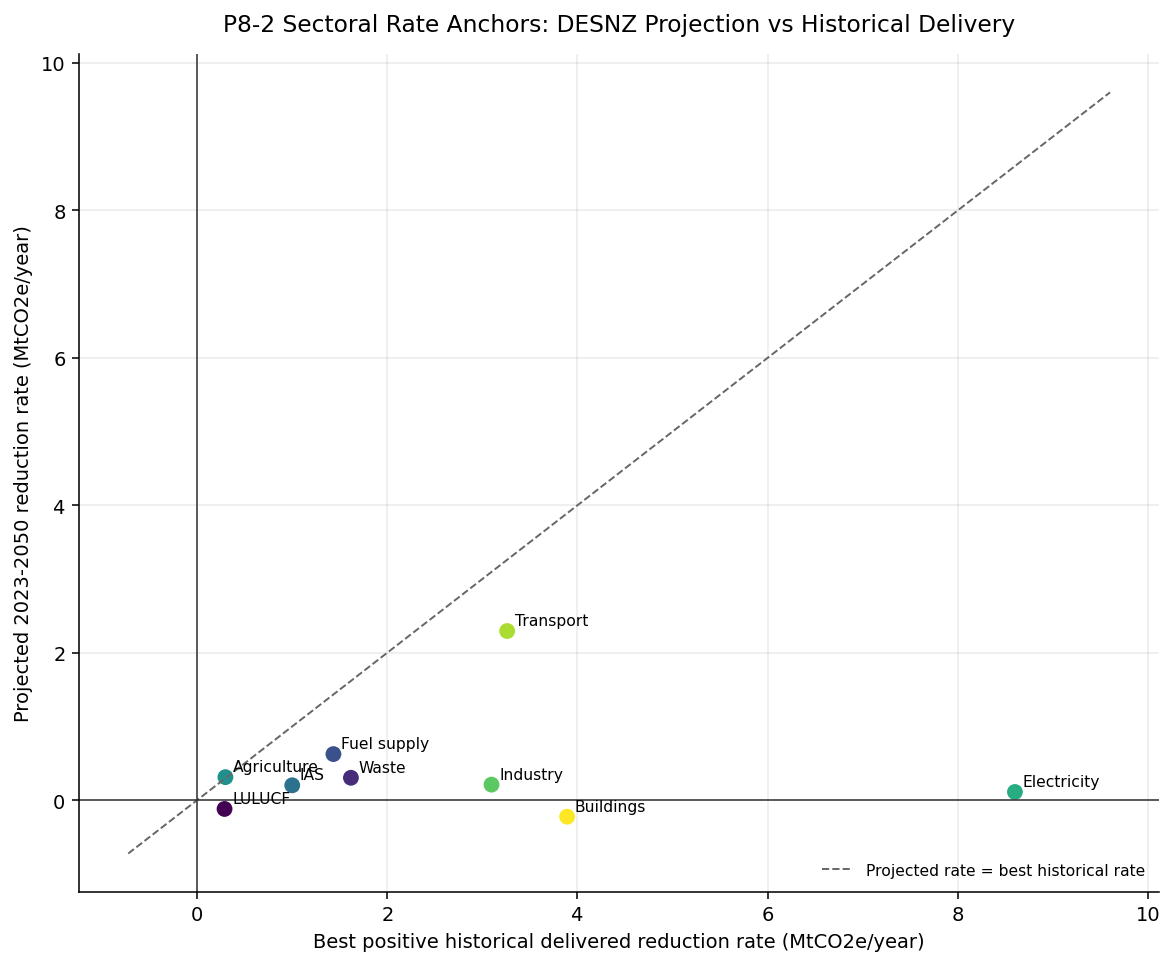

Saved: E:\UCL Final Essay\p8_uncertainty_framework\figures\p8_2_sector_rate_anchor_scatter.jpg


In [7]:
fig, ax = plt.subplots(figsize=(8.5, 7))
plot_df = metrics.copy()

ax.scatter(
    plot_df["best_positive_historical_rate_MtCO2e_per_year"],
    plot_df["projected_rate_2023_2050_MtCO2e_per_year"],
    s=80,
    c=plot_df["rank_2050_residual"],
    cmap="viridis_r",
    edgecolor="white",
    linewidth=0.8,
)

max_val = max(
    plot_df["best_positive_historical_rate_MtCO2e_per_year"].max(),
    plot_df["projected_rate_2023_2050_MtCO2e_per_year"].max(),
) + 1
min_val = min(0, plot_df["projected_rate_2023_2050_MtCO2e_per_year"].min() - 0.5)
ax.plot([min_val, max_val], [min_val, max_val], color="#666666", linestyle="--", linewidth=1, label="Projected rate = best historical rate")
ax.axhline(0, color="#333333", linewidth=0.8)
ax.axvline(0, color="#333333", linewidth=0.8)

for _, row in plot_df.iterrows():
    label = row["tes_sector"].replace("Buildings and product uses", "Buildings").replace("Domestic Transport", "Transport").replace("Electricity supply", "Electricity")
    ax.text(
        row["best_positive_historical_rate_MtCO2e_per_year"] + 0.08,
        row["projected_rate_2023_2050_MtCO2e_per_year"] + 0.08,
        label,
        fontsize=8,
    )

ax.set_title("P8-2 Sectoral Rate Anchors: DESNZ Projection vs Historical Delivery", fontsize=12, pad=12)
ax.set_xlabel("Best positive historical delivered reduction rate (MtCO2e/year)")
ax.set_ylabel("Projected 2023-2050 reduction rate (MtCO2e/year)")
ax.legend(frameon=False, fontsize=8, loc="lower right")
ax.grid(alpha=0.25)
fig.tight_layout()

fig_path_scatter = FIG_DIR / "p8_2_sector_rate_anchor_scatter.jpg"
fig.savefig(fig_path_scatter, format="jpg", bbox_inches="tight")
plt.show()
print("Saved:", fig_path_scatter)

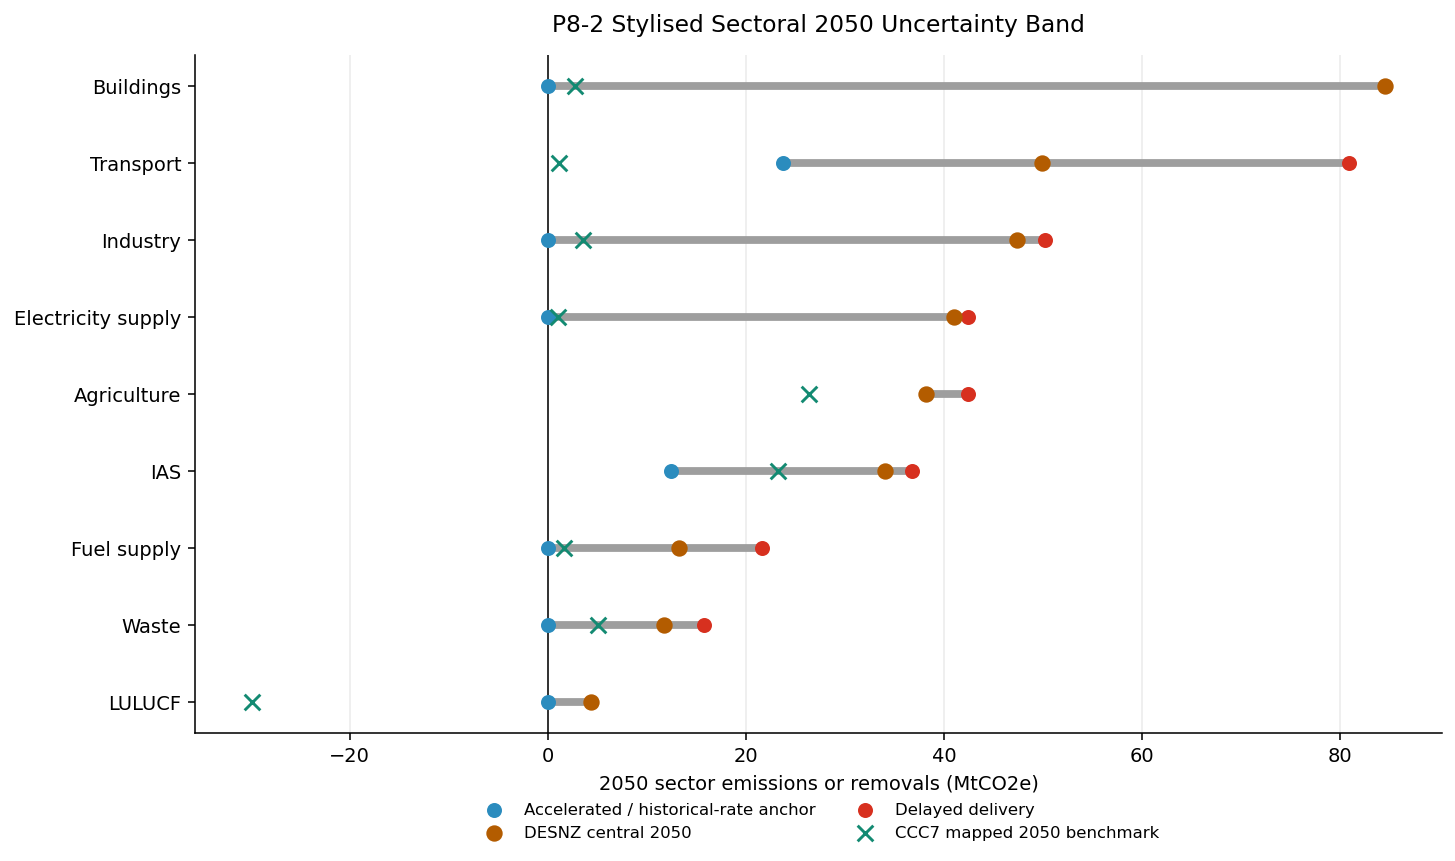

Saved: E:\UCL Final Essay\p8_uncertainty_framework\figures\p8_2_sector_uncertainty_band_2050.jpg


In [8]:
plot_df = uncertainty.sort_values("desnz_central_2050_MtCO2e", ascending=True).copy()
y = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(10.5, 6.8))

for i, row in enumerate(plot_df.itertuples()):
    ax.plot(
        [row.accelerated_historical_anchor_2050_MtCO2e, row.delayed_delivery_2050_MtCO2e],
        [i, i],
        color="#9e9e9e",
        linewidth=4,
        solid_capstyle="round",
    )

ax.scatter(plot_df["accelerated_historical_anchor_2050_MtCO2e"], y, color="#2b8cbe", s=45, label="Accelerated / historical-rate anchor", zorder=3)
ax.scatter(plot_df["desnz_central_2050_MtCO2e"], y, color="#b35c00", s=55, label="DESNZ central 2050", zorder=4)
ax.scatter(plot_df["delayed_delivery_2050_MtCO2e"], y, color="#d7301f", s=45, label="Delayed delivery", zorder=3)
ax.scatter(plot_df["ccc7_2050_MtCO2e"], y, color="#138a72", marker="x", s=65, label="CCC7 mapped 2050 benchmark", zorder=5)

labels = plot_df["tes_sector"].str.replace("Buildings and product uses", "Buildings", regex=False).str.replace("Domestic Transport", "Transport", regex=False)
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("2050 sector emissions or removals (MtCO2e)")
ax.set_title("P8-2 Stylised Sectoral 2050 Uncertainty Band", fontsize=12, pad=12)
ax.grid(axis="x", alpha=0.25)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False, fontsize=8.5)
fig.tight_layout(rect=[0, 0.07, 1, 1])

fig_path_band = FIG_DIR / "p8_2_sector_uncertainty_band_2050.jpg"
fig.savefig(fig_path_band, format="jpg", bbox_inches="tight")
plt.show()
print("Saved:", fig_path_band)

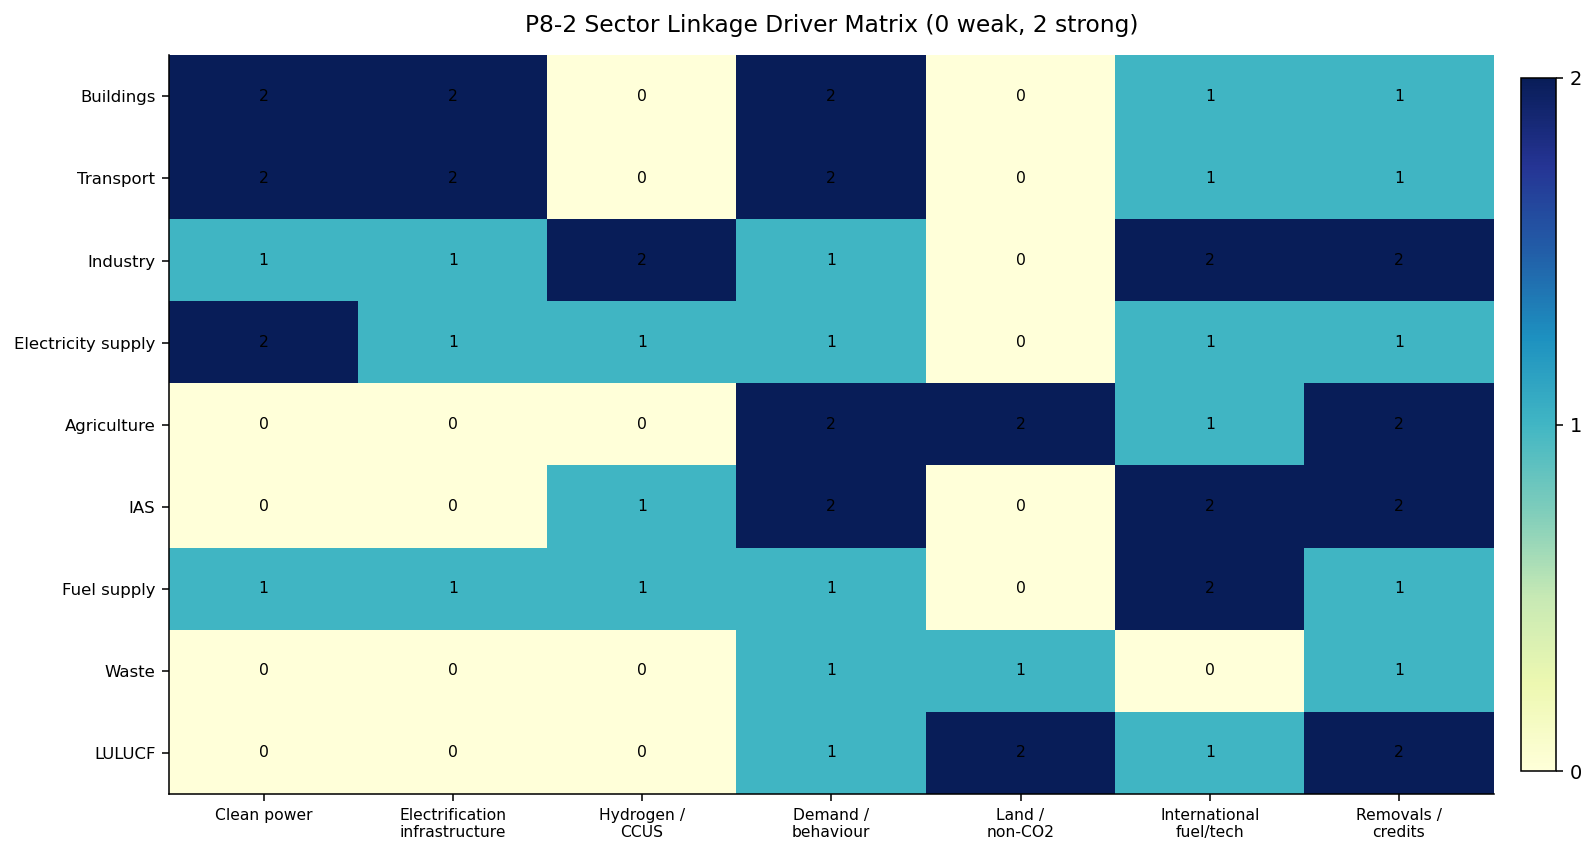

Saved: E:\UCL Final Essay\p8_uncertainty_framework\figures\p8_2_sector_linkage_driver_matrix.jpg


In [9]:
heat_df = driver_matrix.set_index("tes_sector")[driver_cols]

fig, ax = plt.subplots(figsize=(11.5, 6.2))
im = ax.imshow(heat_df.values, cmap="YlGnBu", vmin=0, vmax=2, aspect="auto")

ax.set_xticks(np.arange(len(driver_cols)))
ax.set_xticklabels(
    [
        "Clean power",
        "Electrification\ninfrastructure",
        "Hydrogen /\nCCUS",
        "Demand /\nbehaviour",
        "Land /\nnon-CO2",
        "International\nfuel/tech",
        "Removals /\ncredits",
    ],
    fontsize=8,
)
ax.set_yticks(np.arange(len(heat_df.index)))
ax.set_yticklabels([s.replace("Buildings and product uses", "Buildings").replace("Domestic Transport", "Transport") for s in heat_df.index], fontsize=8.5)

for i in range(heat_df.shape[0]):
    for j in range(heat_df.shape[1]):
        ax.text(j, i, str(int(heat_df.iloc[i, j])), ha="center", va="center", color="black", fontsize=8)

ax.set_title("P8-2 Sector Linkage Driver Matrix (0 weak, 2 strong)", fontsize=12, pad=12)
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, ticks=[0, 1, 2])
fig.tight_layout()

fig_path_matrix = FIG_DIR / "p8_2_sector_linkage_driver_matrix.jpg"
fig.savefig(fig_path_matrix, format="jpg", bbox_inches="tight")
plt.show()
print("Saved:", fig_path_matrix)

## 7. Bilingual Results Summary

In [10]:
top_residual = metrics.sort_values("rank_2050_residual").head(4)["tes_sector"].tolist()
reversal_sectors = metrics.loc[metrics["rate_anchor_interpretation"].eq("Projected reversal after historical decline"), "tes_sector"].tolist()
slowdown_sectors = metrics.loc[metrics["rate_anchor_interpretation"].str.contains("slower", case=False, na=False), "tes_sector"].tolist()

summary_en = f'''
P8-2 result summary

P8-2 converts the P6 sectoral ranking into an uncertainty and linkage framework. The largest DESNZ 2050 residual sectors remain {", ".join(top_residual)}, but the interpretation is no longer only a static ranking. The rate-anchor comparison shows whether each sector's projected 2023-2050 reduction is consistent with, slower than, or reversed relative to historical delivered rates.

Two points are especially important for the dissertation. First, electricity, domestic transport, and buildings form a coupled electrification cluster: they can move together if clean power, infrastructure, and end-use uptake align. Second, agriculture, IAS, parts of industry, waste, and LULUCF are less directly solved by clean electricity and therefore remain important near-miss or residual-emissions risks.

The stylised 2050 sensitivity band should not be presented as a probability forecast. Its value is interpretive: it shows where the DESNZ central estimate may be vulnerable to delivery slowdown, and where faster historical-rate delivery could shrink residual emissions. Sectors flagged for slowdown or reversal include {", ".join(reversal_sectors + slowdown_sectors)}. This provides a direct bridge from P6 to the P8 uncertainty framework and prepares the next step: the 2x2 scenario matrix and near-miss mini-scenarios.
'''.strip()

summary_cn = f'''
P8-2 结果总结

P8-2 把 P6 的部门残余排放排名转化为“不确定性和部门联动框架”。DESNZ 2050 年残余排放最高的部门仍然是 {", ".join(top_residual)}，但现在解释不再只是静态排名，而是进一步判断每个部门 2023-2050 年的 projected reduction 是否与历史实际减排速度相符、明显放缓，或出现反向变化。

两个点对论文尤其关键。第一，电力、国内交通、建筑/产品使用构成一个相互联动的 electrification cluster：如果清洁电力、基础设施和终端技术采用同时推进，它们可以一起改善。第二，农业、IAS、部分工业、废弃物和 LULUCF 不能主要靠清洁电力解决，因此会成为 near-miss 或 residual-emissions 风险。

这里的 2050 sensitivity band 不能当作概率预测。它的作用是解释性：展示 DESNZ central estimate 在哪些部门容易受 delivery slowdown 影响，以及如果延续较快历史减排速度，哪些残余排放可能收缩。被标记为放缓或反向变化的部门包括 {", ".join(reversal_sectors + slowdown_sectors)}。这一步把 P6 连接到 P8 uncertainty framework，并为下一步 2x2 scenario matrix 和 near-miss mini-scenarios 做准备。
'''.strip()

summary_text = summary_en + "\n\n" + summary_cn
summary_path = TABLE_DIR / "p8_2_results_summary_bilingual.txt"
summary_path.write_text(summary_text, encoding="utf-8")

print(summary_text)
print("\nSaved:", summary_path)

P8-2 result summary

P8-2 converts the P6 sectoral ranking into an uncertainty and linkage framework. The largest DESNZ 2050 residual sectors remain Buildings and product uses, Domestic Transport, Industry, Electricity supply, but the interpretation is no longer only a static ranking. The rate-anchor comparison shows whether each sector's projected 2023-2050 reduction is consistent with, slower than, or reversed relative to historical delivered rates.

Two points are especially important for the dissertation. First, electricity, domestic transport, and buildings form a coupled electrification cluster: they can move together if clean power, infrastructure, and end-use uptake align. Second, agriculture, IAS, parts of industry, waste, and LULUCF are less directly solved by clean electricity and therefore remain important near-miss or residual-emissions risks.

The stylised 2050 sensitivity band should not be presented as a probability forecast. Its value is interpretive: it shows where th

## 8. Quality Checks

In [11]:
checks = []

checks.append({
    "check": "sector_count",
    "expected": "9 DESNZ TES / memo sectors",
    "actual": str(sector_long["tes_sector"].nunique()),
    "status": "PASS" if sector_long["tes_sector"].nunique() == 9 else "CHECK",
})
checks.append({
    "check": "selected_years_available",
    "expected": ", ".join(map(str, selected_years)),
    "actual": ", ".join(map(str, sorted(set(sector_long["year"]).intersection(selected_years)))),
    "status": "PASS" if set(selected_years).issubset(set(sector_long["year"])) else "CHECK",
})
checks.append({
    "check": "uncertainty_band_order",
    "expected": "accelerated <= delayed for all sectors",
    "actual": str(bool((uncertainty["accelerated_historical_anchor_2050_MtCO2e"] <= uncertainty["delayed_delivery_2050_MtCO2e"]).all())),
    "status": "PASS" if (uncertainty["accelerated_historical_anchor_2050_MtCO2e"] <= uncertainty["delayed_delivery_2050_MtCO2e"]).all() else "CHECK",
})
checks.append({
    "check": "driver_matrix_complete",
    "expected": "all sectors scored for all drivers",
    "actual": str(driver_matrix[driver_cols].notna().all().all()),
    "status": "PASS" if driver_matrix[driver_cols].notna().all().all() else "CHECK",
})
checks.append({
    "check": "figures_saved_as_jpg",
    "expected": "3 jpg figures",
    "actual": f"{fig_path_scatter.exists()} / {fig_path_band.exists()} / {fig_path_matrix.exists()}",
    "status": "PASS" if fig_path_scatter.exists() and fig_path_band.exists() and fig_path_matrix.exists() else "CHECK",
})

quality_checks = pd.DataFrame(checks)
quality_checks.to_csv(TABLE_DIR / "p8_2_quality_checks.csv", index=False)
display(quality_checks)

if not all(quality_checks["status"].eq("PASS")):
    print("One or more checks need attention before using P8-2 outputs.")
else:
    print("All P8-2 quality checks passed.")

,check,expected,actual,status
0,sector_count,9 DESNZ TES / memo sectors,9,PASS
1,selected_years_available,"1990, 2008, 2018, 2023, 2030, 2035, 2050","1990, 2008, 2018, 2023, 2030, 2035, 2050",PASS
2,uncertainty_band_order,accelerated <= delayed for all sectors,True,PASS
3,driver_matrix_complete,all sectors scored for all drivers,True,PASS
4,figures_saved_as_jpg,3 jpg figures,True / True / True,PASS


All P8-2 quality checks passed.
